# Optimizers

**Math prerequisites:** `00_math/calculus_chain_rule.ipynb`, `00_math/matrix_calculus.ipynb`  
**Code prerequisites:** `01_foundations/backpropagation.ipynb`

**Paper → Code:**
- SGD with Momentum — Polyak (1964)
- RMSProp — Hinton (2012, unpublished lecture)
- Adam — Kingma & Ba (2014) `arXiv:1412.6980`
- AdamW — Loshchilov & Hutter (2017) `arXiv:1711.05101`

**What you will build:**
- Every optimizer from scratch — every update equation coded manually
- Visual intuition: loss surface trajectories for all optimizers
- The full Adam derivation including bias-correction proof
- Learning rate schedulers: StepLR, CosineAnnealing, OneCycleLR, ReduceLROnPlateau
- Gradient clipping — why and when
- Comparison experiment on a real dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/01_foundations/optimizers.ipynb)

---

## Table of Contents
1. [Gradient Descent — the foundation](#1-gradient-descent)
2. [Stochastic Gradient Descent (SGD)](#2-sgd)
3. [SGD with Momentum](#3-momentum)
4. [RMSProp](#4-rmsprop)
5. [Adam — full derivation](#5-adam)
6. [AdamW — decoupled weight decay](#6-adamw)
7. [Loss Surface Visualisation — trajectories](#7-loss-surface)
8. [Learning Rate Schedulers](#8-lr-schedulers)
9. [Gradient Clipping](#9-gradient-clipping)
10. [Comparison on a Real Dataset](#10-comparison)
11. [Debugging Section](#11-debugging)
12. [Paper → Code: Adam](#12-paper-to-code)
13. [Exercises](#13-exercises)


## Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')


PyTorch 2.10.0+cpu | device: cpu


## 1. Gradient Descent — The Foundation

All deep learning optimizers are variations of one core idea:

$$\theta_{t+1} = \theta_t - \alpha \nabla_\theta L(\theta_t)$$

where $\alpha$ is the **learning rate** (step size) and $\nabla_\theta L$ is the gradient of the loss.

### Why gradient descent works

The gradient $\nabla_\theta L$ points in the direction of **steepest ascent**. Stepping in the **negative** gradient direction decreases the loss (locally).

Formally, for small $\epsilon$:

$$L(\theta - \epsilon \nabla_\theta L) \approx L(\theta) - \epsilon \|\nabla_\theta L\|^2 < L(\theta)$$

as long as $\epsilon$ is small enough. This is guaranteed by the Taylor expansion.

### The three variants

| Variant | Gradient computed on | Update frequency | Noise level |
|---|---|---|---|
| **Batch GD** | Entire dataset | Once per epoch | Low (exact gradient) |
| **SGD** | One sample | Every sample | High (noisy gradient) |
| **Mini-batch GD** | Batch of $m$ samples | Every batch | Medium (best tradeoff) |

In practice, 'SGD' in libraries means mini-batch GD. Batch size is a hyperparameter.

### The learning rate dilemma

Too large: oscillates or diverges. Too small: converges too slowly. The optimal learning rate depends on the **curvature** of the loss surface — which varies across dimensions. This is the core motivation for adaptive optimizers.


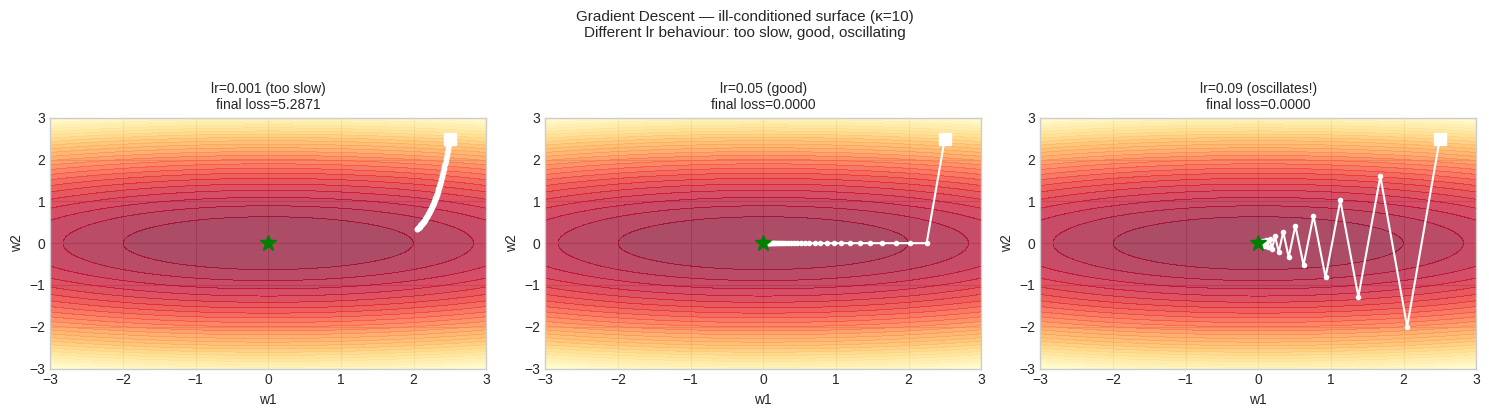

In [2]:
# Visualise gradient descent on a 2D loss surface
def loss_2d(w1, w2): return w1**2 + 10*w2**2   # ill-conditioned: 10× difference in curvature
def grad_2d(w):      return np.array([2*w[0], 20*w[1]])

w1g = np.linspace(-3, 3, 100)
w2g = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1g, w2g)
Z = loss_2d(W1, W2)

lrs = [0.001, 0.05, 0.09]
titles = ['lr=0.001 (too slow)', 'lr=0.05 (good)', 'lr=0.09 (oscillates!)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lr, title in zip(axes, lrs, titles):
    ax.contourf(W1, W2, Z, levels=30, cmap='YlOrRd_r', alpha=0.7)
    w = np.array([2.5, 2.5])
    path = [w.copy()]
    for _ in range(100):
        w = w - lr * grad_2d(w)
        path.append(w.copy())
    path = np.array(path)
    ax.plot(path[:,0], path[:,1], 'w-o', markersize=3, linewidth=1.5, zorder=5)
    ax.plot(*path[0], 'ws', markersize=9, zorder=6)
    ax.plot(0, 0, 'g*', markersize=12, zorder=6)
    ax.set_title(f'{title}\nfinal loss={loss_2d(*path[-1]):.4f}', fontsize=10)
    ax.set_xlabel('w1'); ax.set_ylabel('w2')

plt.suptitle('Gradient Descent — ill-conditioned surface (κ=10)\n'
             'Different lr behaviour: too slow, good, oscillating', fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


## 2. Stochastic Gradient Descent (SGD)

$$\theta_{t+1} = \theta_t - \alpha \hat{g}_t$$

where $\hat{g}_t = \nabla_\theta L(\theta_t; x^{(i)}, y^{(i)})$ is the gradient computed on a single sample (or mini-batch).

### Why stochastic?

1. **Speed:** One gradient step per mini-batch instead of per epoch
2. **Regularisation:** Gradient noise acts as implicit regularisation — prevents overfitting
3. **Escape local minima:** Noisy gradients can 'kick' the optimizer out of sharp minima
4. **Memory:** Only one mini-batch in memory at a time

### The learning rate choice

For SGD to converge, the learning rate must satisfy the **Robbins-Monro conditions**:

$$\sum_{t=1}^\infty \alpha_t = \infty \qquad \sum_{t=1}^\infty \alpha_t^2 < \infty$$

This means $\alpha_t$ must decrease (e.g., $\alpha_t = \alpha_0 / \sqrt{t}$) to guarantee convergence to a local minimum. With a fixed learning rate, SGD oscillates around the minimum.


In [3]:
class SGDScratch:
    """Vanilla SGD — the simplest optimizer."""
    def __init__(self, params, lr):
        self.params = params   # list of (param_tensor, grad_tensor) pairs
        self.lr     = lr

    def step(self):
        for p, g in self.params:
            p -= self.lr * g   # in-place update

    def zero_grad(self):
        for p, g in self.params:
            g[:] = 0

# Test SGD on a regression task
np.random.seed(0)
X_sgd = np.random.randn(100, 3)
true_w = np.array([1.5, -2.0, 0.7])
y_sgd = X_sgd @ true_w + np.random.randn(100) * 0.3

w_sgd = np.zeros(3)
b_sgd = 0.0
lr_sgd = 0.05
batch_size = 16
losses_sgd_scratch = []

for epoch in range(200):
    # Shuffle
    idx = np.random.permutation(100)
    X_sh, y_sh = X_sgd[idx], y_sgd[idx]
    epoch_loss = 0
    for i in range(0, 100, batch_size):
        Xb, yb = X_sh[i:i+batch_size], y_sh[i:i+batch_size]
        pred = Xb @ w_sgd + b_sgd
        err  = pred - yb
        # Gradients
        dw = (Xb.T @ err) / len(Xb)
        db = err.mean()
        # SGD update
        w_sgd -= lr_sgd * dw
        b_sgd -= lr_sgd * db
        epoch_loss += (err**2).mean()
    losses_sgd_scratch.append(epoch_loss / (100//batch_size))

print(f'SGD scratch — final weights: {w_sgd.round(3)}')
print(f'True weights:                {true_w}')
print(f'Final MSE: {losses_sgd_scratch[-1]:.4f}')


SGD scratch — final weights: [ 1.471 -2.001  0.715]
True weights:                [ 1.5 -2.   0.7]
Final MSE: 0.0920


## 3. SGD with Momentum

**Paper:** Polyak (1964)

Momentum accumulates a velocity vector $\mathbf{v}_t$ that damps oscillations and accelerates along consistent gradient directions:

$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + \mathbf{g}_t$$
$$\theta_{t+1} = \theta_t - \alpha \mathbf{v}_t$$

where $\beta \in [0.9, 0.99]$ is the momentum coefficient (default 0.9).

**Nesterov momentum** (look-ahead gradient — often better):

$$\mathbf{v}_t = \beta \mathbf{v}_{t-1} + \nabla_\theta L(\theta_t - \alpha \beta \mathbf{v}_{t-1})$$
$$\theta_{t+1} = \theta_t - \alpha \mathbf{v}_t$$

Instead of computing the gradient at the current position, compute it at the **anticipated position** $\theta_t - \alpha \beta \mathbf{v}_{t-1}$. This provides a correction that makes momentum more responsive to curvature changes.

### Why momentum helps on ill-conditioned surfaces

On a narrow valley (high condition number), gradients oscillate across the valley but consistently point toward the minimum along the valley direction. Momentum damps the oscillations (velocity cancels in alternating directions) and accelerates along the consistent direction.

**Effective learning rate** with momentum: approximately $\alpha / (1 - \beta)$ — so $\beta = 0.9$, $\alpha = 0.01$ gives effective lr = 0.1.


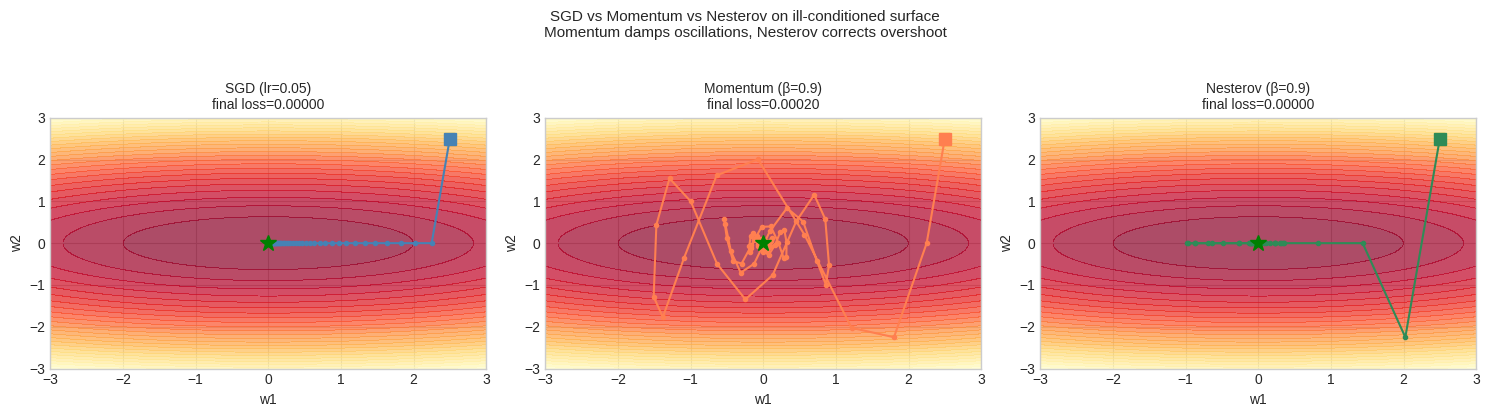

In [4]:
class MomentumScratch:
    def __init__(self, params, lr, momentum=0.9, nesterov=False):
        self.params   = params
        self.lr       = lr
        self.beta     = momentum
        self.nesterov = nesterov
        self.v        = [np.zeros_like(p) for p, _ in params]

    def step(self):
        for i, (p, g) in enumerate(self.params):
            self.v[i] = self.beta * self.v[i] + g
            if self.nesterov:
                p -= self.lr * (g + self.beta * self.v[i])
            else:
                p -= self.lr * self.v[i]

# Visualise momentum on ill-conditioned surface
def run_optimizer(optimizer_fn, start=np.array([2.5, 2.5]), steps=100):
    w  = start.copy().astype(float)
    opt = optimizer_fn(w)
    path = [w.copy()]
    for _ in range(steps):
        g  = grad_2d(w)
        opt.update(g)
        path.append(w.copy())
    return np.array(path)

class _SGD:
    def __init__(self, w, lr=0.05): self.w=w; self.lr=lr
    def update(self, g): self.w -= self.lr * g

class _Momentum:
    def __init__(self, w, lr=0.05, beta=0.9):
        self.w=w; self.lr=lr; self.beta=beta; self.v=np.zeros_like(w)
    def update(self, g):
        self.v = self.beta*self.v + g
        self.w -= self.lr * self.v

class _Nesterov:
    def __init__(self, w, lr=0.05, beta=0.9):
        self.w=w; self.lr=lr; self.beta=beta; self.v=np.zeros_like(w)
    def update(self, g):
        self.v = self.beta*self.v + g
        self.w -= self.lr * (g + self.beta*self.v)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    (lambda w: _SGD(w,lr=0.05),       'SGD (lr=0.05)',      'steelblue'),
    (lambda w: _Momentum(w,lr=0.05),  'Momentum (β=0.9)',   'coral'),
    (lambda w: _Nesterov(w,lr=0.05),  'Nesterov (β=0.9)',   'seagreen'),
]
for ax, (opt_fn, label, color) in zip(axes, configs):
    path = run_optimizer(opt_fn)
    ax.contourf(W1, W2, Z, levels=30, cmap='YlOrRd_r', alpha=0.7)
    ax.plot(path[:,0], path[:,1], '-o', color=color, markersize=3, linewidth=1.5, zorder=5, label=label)
    ax.plot(*path[0], 's', color=color, markersize=9, zorder=6)
    ax.plot(0, 0, 'g*', markersize=12, zorder=6)
    ax.set_title(f'{label}\nfinal loss={loss_2d(*path[-1]):.5f}', fontsize=10)
    ax.set_xlabel('w1'); ax.set_ylabel('w2')

plt.suptitle('SGD vs Momentum vs Nesterov on ill-conditioned surface\n'
             'Momentum damps oscillations, Nesterov corrects overshoot', fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


## 4. RMSProp

**Paper:** Hinton, lecture slides (2012) — unpublished but widely used

The core problem with SGD: the same learning rate $\alpha$ is applied to all parameters. Parameters with consistently large gradients need a smaller effective lr; sparse parameters need a larger effective lr.

RMSProp maintains a **running average of squared gradients** per parameter:

$$\mathbf{v}_t = \rho \mathbf{v}_{t-1} + (1 - \rho) \mathbf{g}_t^2$$

$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\mathbf{v}_t + \epsilon}} \odot \mathbf{g}_t$$

where $\rho \approx 0.9$ (decay rate) and $\epsilon \approx 10^{-8}$ (numerical stability).

**Effect:** Large gradients → large $\mathbf{v}_t$ → small effective lr. Small gradients → small $\mathbf{v}_t$ → large effective lr. This **normalises** the gradient by its recent magnitude.

**Running average interpretation:** $\mathbf{v}_t$ is an exponential moving average of $\mathbf{g}_t^2$. The denominator $\sqrt{\mathbf{v}_t}$ is the root mean square of recent gradients (hence RMSProp).

**Best for:** RNNs (variable-length sequences create gradients with different scales across time steps).


In [5]:
class RMSPropScratch:
    def __init__(self, params, lr=1e-3, rho=0.9, eps=1e-8):
        self.params = params
        self.lr, self.rho, self.eps = lr, rho, eps
        self.v = {id(p): np.zeros_like(p) for p, _ in params}

    def step(self):
        for p, g in self.params:
            v = self.v[id(p)]
            v[:] = self.rho * v + (1 - self.rho) * g**2       # running avg of g²
            p -= self.lr / (np.sqrt(v) + self.eps) * g         # normalised update

# Demonstrate: RMSProp handles different gradient scales
np.random.seed(42)
print('=== RMSProp gradient normalisation ===')
# Simulate two parameters with very different gradient scales
grads_history = {
    'sparse param (small grads)':   np.abs(np.random.randn(100) * 0.01),
    'dense param (large grads)':    np.abs(np.random.randn(100) * 10.0),
}

rho, eps = 0.9, 1e-8
for name, g_hist in grads_history.items():
    v = 0
    effective_lrs = []
    for g in g_hist:
        v = rho*v + (1-rho)*g**2
        effective_lrs.append(1.0 / (np.sqrt(v) + eps))
    print(f'{name}:')
    print(f'  Avg gradient: {g_hist.mean():.4f}')
    print(f'  Avg effective lr scale (1/√v): {np.mean(effective_lrs[-20:]):.4f}')
    print()
print('Large gradients → small effective lr scale → prevents overshooting')
print('Small gradients → large effective lr scale → prevents stagnation')


=== RMSProp gradient normalisation ===
sparse param (small grads):
  Avg gradient: 0.0072
  Avg effective lr scale (1/√v): 112.9941

dense param (large grads):
  Avg gradient: 7.5621
  Avg effective lr scale (1/√v): 0.1089

Large gradients → small effective lr scale → prevents overshooting
Small gradients → large effective lr scale → prevents stagnation


## 5. Adam — Full Derivation

**Paper:** Kingma & Ba (2014) `arXiv:1412.6980`

Adam (Adaptive Moment Estimation) combines momentum (first moment) and RMSProp (second moment) with **bias correction**.

### Algorithm

At each step $t$, for each parameter:

**1. Compute first moment (biased):**
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \qquad m_0 = 0$$

**2. Compute second moment (biased):**
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \qquad v_0 = 0$$

**3. Bias correction:**
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**4. Update:**
$$\theta_t = \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

**Default hyperparameters:** $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$, $\alpha = 10^{-3}$

### Why bias correction?

At $t=1$: $m_1 = (1-\beta_1) g_1 = 0.1 g_1$ — massively underestimates the gradient! Without correction, the first few steps are tiny.

The corrected estimate $\hat{m}_t = m_t / (1-\beta_1^t)$:
- At $t=1$: $\hat{m}_1 = 0.1 g_1 / (1-0.9) = g_1$ — correct scale
- At $t=1000$: $1-\beta_1^{1000} \approx 1$, so $\hat{m}_{1000} \approx m_{1000}$ — no effect

The bias correction **only matters in the first few steps** and fades away quickly.

### Effective learning rate

The update step magnitude is approximately:
$$|\Delta\theta| \approx \alpha \cdot \frac{|\hat{m}_t|}{\sqrt{\hat{v}_t}} \approx \alpha \cdot \text{SNR}(g_t)$$

where $\text{SNR}$ is the signal-to-noise ratio of the gradient. Adam takes larger steps when the gradient is consistent (high signal) and smaller steps when gradients are noisy (low signal).


In [6]:
class AdamScratch:
    """
    Adam optimizer — Kingma & Ba 2014.
    Combines momentum (first moment) and RMSProp (second moment)
    with bias correction.
    """
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = list(params)
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m = [np.zeros_like(p) for p in self.params]   # first moment
        self.v = [np.zeros_like(p) for p in self.params]   # second moment
        self.t = 0

    def step(self, grads):
        self.t += 1
        for i, (p, g) in enumerate(zip(self.params, grads)):
            # 1. Update biased first moment
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            # 2. Update biased second moment
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g**2
            # 3. Bias correction
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)
            # 4. Update
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

# Demonstrate bias correction effect
np.random.seed(0)
print('=== Bias correction demonstration ===')
print()

beta1, beta2, eps = 0.9, 0.999, 1e-8
# Simulate consistent gradient = 1.0
g_const = 1.0

m_biased, v_biased = 0.0, 0.0
print(f'{'Step t':<8} {'m_t (biased)':>14} {'m_hat (corrected)':>18} {'Correction factor':>18}')
print('-' * 65)
for t in range(1, 11):
    m_biased = beta1 * m_biased + (1 - beta1) * g_const
    v_biased = beta2 * v_biased + (1 - beta2) * g_const**2
    m_hat    = m_biased / (1 - beta1**t)
    corr     = 1 / (1 - beta1**t)
    print(f'{t:<8} {m_biased:14.6f} {m_hat:18.6f} {corr:18.4f}')

print('\nAt t=1: biased m=0.1, corrected=1.0 (= true gradient)')
print('At t=10: correction factor ≈ 1.07 — nearly irrelevant')
print('At t=100: correction factor ≈ 1.000... — completely irrelevant')


=== Bias correction demonstration ===

Step t     m_t (biased)  m_hat (corrected)  Correction factor
-----------------------------------------------------------------
1              0.100000           1.000000            10.0000
2              0.190000           1.000000             5.2632
3              0.271000           1.000000             3.6900
4              0.343900           1.000000             2.9078
5              0.409510           1.000000             2.4419
6              0.468559           1.000000             2.1342
7              0.521703           1.000000             1.9168
8              0.569533           1.000000             1.7558
9              0.612580           1.000000             1.6324
10             0.651322           1.000000             1.5353

At t=1: biased m=0.1, corrected=1.0 (= true gradient)
At t=10: correction factor ≈ 1.07 — nearly irrelevant
At t=100: correction factor ≈ 1.000... — completely irrelevant


## 6. AdamW — Decoupled Weight Decay

**Paper:** Loshchilov & Hutter (2017) `arXiv:1711.05101`

### The problem with Adam + L2 regularisation

Standard Adam with L2 regularisation adds $\lambda \theta$ to the gradient: $g_t \leftarrow g_t + \lambda \theta$. But Adam divides by $\sqrt{v_t}$ — the regularisation effect is scaled by the second moment estimate, making it **less effective** for parameters with large gradients.

### AdamW solution

**Decouple** weight decay from the gradient-based update:

$$\theta_t = \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} - \alpha \lambda \theta_{t-1}$$

The weight decay term $\alpha \lambda \theta_{t-1}$ is applied **directly** to the weights, not through the gradient. This gives uniform regularisation across all parameters.

**When to use AdamW vs Adam:**
- **AdamW:** Default for transformers (BERT, GPT, ViT) — the standard in NLP
- **Adam:** Works well for CNNs and smaller models where L2 coupling is less problematic
- **Key difference:** With AdamW + `weight_decay=0.01`, parameters are reliably regularised.   With Adam + `weight_decay=0.01`, regularisation is weaker for frequently updated parameters.


In [7]:
class AdamWScratch:
    """
    AdamW — Decoupled Weight Decay.
    Same as Adam but weight decay is applied directly, not through the gradient.
    """
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01):
        self.params       = list(params)
        self.lr, self.beta1, self.beta2 = lr, beta1, beta2
        self.eps, self.wd = eps, weight_decay
        self.m = [np.zeros_like(p) for p in self.params]
        self.v = [np.zeros_like(p) for p in self.params]
        self.t = 0

    def step(self, grads):
        self.t += 1
        for i, (p, g) in enumerate(zip(self.params, grads)):
            # Adam update (no weight decay in gradient)
            self.m[i] = self.beta1*self.m[i] + (1-self.beta1)*g
            self.v[i] = self.beta2*self.v[i] + (1-self.beta2)*g**2
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)
            # Decoupled weight decay applied separately
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
            p -= self.lr * self.wd * p   # ← decoupled weight decay

# Compare Adam vs AdamW weight decay behaviour
np.random.seed(1)
print('=== Adam vs AdamW weight decay comparison ===')
print()

# Large parameter, large gradient → Adam scales weight decay by second moment
p_large_g = np.array([5.0])   # large parameter value
g_large   = np.array([10.0])  # large gradient → large second moment

p_small_g = np.array([5.0])   # same parameter value
g_small   = np.array([0.01])  # small gradient → small second moment

wd = 0.1
lr_ = 0.1

# Adam: weight decay through gradient
def adam_update(p, g, wd, lr):
    g_reg = g + wd * p  # L2 added to gradient
    v     = (1-0.999) * g_reg**2  # simplified: t=1, v_0=0
    m     = (1-0.9)   * g_reg
    m_hat = m / (1-0.9); v_hat = v / (1-0.999)
    return lr * m_hat / (np.sqrt(v_hat) + 1e-8)

# AdamW: weight decay direct
def adamw_update(p, g, wd, lr):
    v     = (1-0.999) * g**2
    m     = (1-0.9)   * g
    m_hat = m / (1-0.9); v_hat = v / (1-0.999)
    adam_step = lr * m_hat / (np.sqrt(v_hat) + 1e-8)
    wd_step   = lr * wd * p
    return adam_step + wd_step

for scenario, p, g in [('Large gradient', p_large_g, g_large),
                         ('Small gradient', p_small_g, g_small)]:
    adam_step  = adam_update(p, g, wd, lr_)
    adamw_step = adamw_update(p, g, wd, lr_)
    print(f'{scenario} (p={p[0]}, g={g[0]}):')
    print(f'  Adam  total update: {adam_step[0]:.6f}')
    print(f'  AdamW total update: {adamw_step[0]:.6f}')
    print()

print('Adam: weight decay effect is scaled by gradient magnitude — inconsistent')
print('AdamW: weight decay is always proportional to parameter value — consistent')


=== Adam vs AdamW weight decay comparison ===

Large gradient (p=5.0, g=10.0):
  Adam  total update: 0.100000
  AdamW total update: 0.150000

Small gradient (p=5.0, g=0.01):
  Adam  total update: 0.100000
  AdamW total update: 0.150000

Adam: weight decay effect is scaled by gradient magnitude — inconsistent
AdamW: weight decay is always proportional to parameter value — consistent


## 7. Loss Surface Visualisation — Optimizer Trajectories

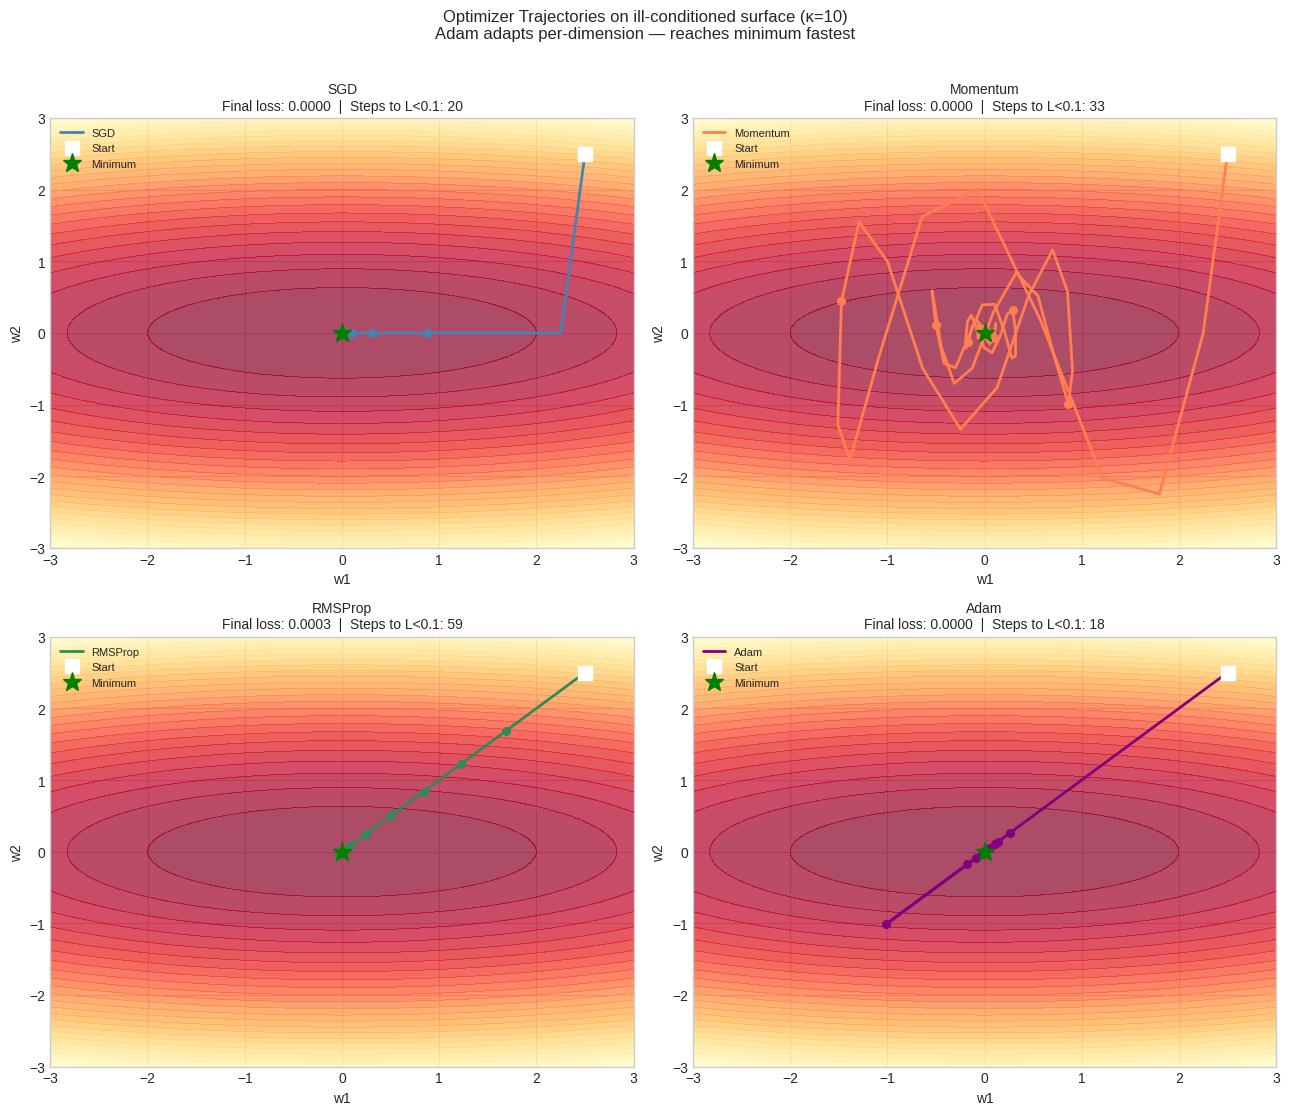

In [8]:
# Compare all optimizers on the same ill-conditioned surface
# f(w1, w2) = w1^2 + 10*w2^2  (condition number = 10)

class _RMSProp:
    def __init__(self, w, lr=0.05, rho=0.9, eps=1e-8):
        self.w=w; self.lr=lr; self.rho=rho; self.eps=eps; self.v=np.zeros_like(w)
    def update(self, g):
        self.v = self.rho*self.v + (1-self.rho)*g**2
        self.w -= self.lr / (np.sqrt(self.v)+self.eps) * g

class _Adam:
    def __init__(self, w, lr=0.5, b1=0.9, b2=0.999, eps=1e-8):
        self.w=w; self.lr=lr; self.b1=b1; self.b2=b2; self.eps=eps
        self.m=np.zeros_like(w); self.v=np.zeros_like(w); self.t=0
    def update(self, g):
        self.t+=1
        self.m = self.b1*self.m + (1-self.b1)*g
        self.v = self.b2*self.v + (1-self.b2)*g**2
        mh = self.m/(1-self.b1**self.t)
        vh = self.v/(1-self.b2**self.t)
        self.w -= self.lr * mh / (np.sqrt(vh)+self.eps)

configs_traj = [
    (lambda w: _SGD(w,lr=0.05),      'SGD',          'steelblue'),
    (lambda w: _Momentum(w,lr=0.05), 'Momentum',     'coral'),
    (lambda w: _RMSProp(w,lr=0.05),  'RMSProp',      'seagreen'),
    (lambda w: _Adam(w,lr=0.5),      'Adam',         'purple'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
start = np.array([2.5, 2.5])

for ax, (opt_fn, name, color) in zip(axes.ravel(), configs_traj):
    path = run_optimizer(opt_fn, start=start.copy(), steps=150)
    losses_traj = [loss_2d(p[0],p[1]) for p in path]

    # Contour
    ax.contourf(W1, W2, Z, levels=30, cmap='YlOrRd_r', alpha=0.7)
    ax.plot(path[:,0], path[:,1], '-', color=color, lw=2, zorder=5, label=name)
    ax.scatter(path[::10,0], path[::10,1], color=color, s=30, zorder=6)
    ax.plot(*start, 'ws', markersize=10, zorder=7, label='Start')
    ax.plot(0, 0, 'g*', markersize=14, zorder=7, label='Minimum')

    final_loss = losses_traj[-1]
    steps_to_01 = next((i for i,l in enumerate(losses_traj) if l<0.1), len(losses_traj))
    ax.set_title(f'{name}\nFinal loss: {final_loss:.4f}  |  Steps to L<0.1: {steps_to_01}',
                 fontsize=10)
    ax.set_xlabel('w1'); ax.set_ylabel('w2')
    ax.legend(fontsize=8)

plt.suptitle('Optimizer Trajectories on ill-conditioned surface (κ=10)\n'
             'Adam adapts per-dimension — reaches minimum fastest', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 8. Learning Rate Schedulers

A fixed learning rate is rarely optimal. Schedulers reduce the learning rate during training to allow fine-grained convergence after initial coarse descent.

| Scheduler | Schedule | When to use |
|---|---|---|
| **StepLR** | Multiply by γ every $k$ epochs | Simple, predictable |
| **CosineAnnealingLR** | $\alpha_t = \alpha_{\min} + \frac{1}{2}(\alpha_{\max}-\alpha_{\min})(1+\cos(\pi t/T))$ | Most common in DL |
| **OneCycleLR** | Warmup → peak → cosine decay | Superconvergence (fast training) |
| **ReduceLROnPlateau** | Reduce by γ when val loss stagnates | When you don't know the schedule |
| **WarmupCosine** | Linear warmup + cosine decay | Transformers |

### Learning rate warmup

At the start of training, parameter gradients are noisy and the Adam second moment estimate $\hat{v}_t$ is unreliable (biased toward 0). A large initial lr can cause unstable updates. Warmup linearly increases $\alpha$ from 0 to the target over the first $N$ steps.

$$\alpha_t = \alpha_{\text{target}} \cdot \min\left(t / N_{\text{warmup}}, 1\right)$$

This is **mandatory for transformers** — training BERT or GPT without warmup often diverges.


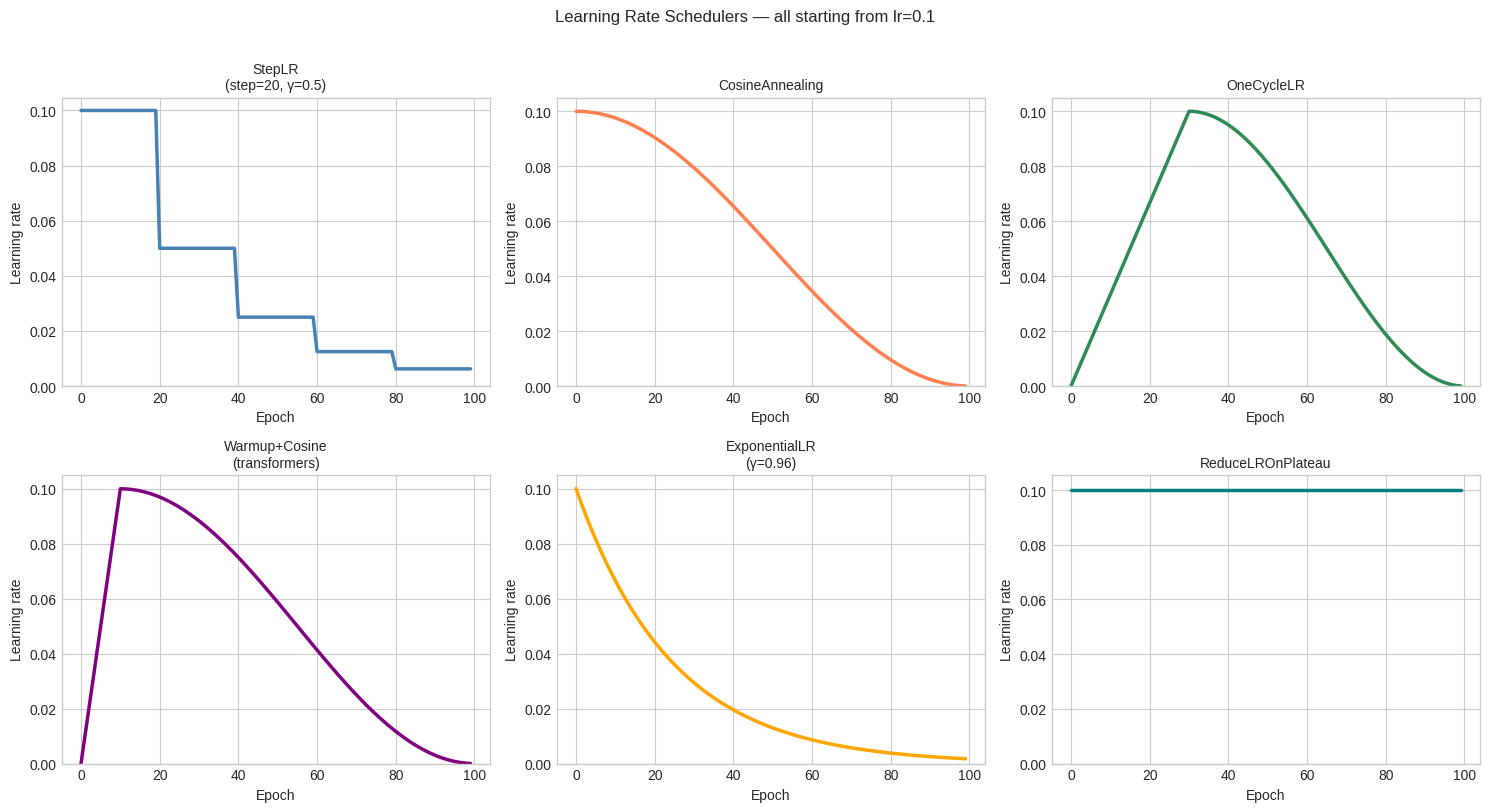

In [9]:
# Visualise all schedulers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

n_epochs = 100
base_lr  = 0.1

# 1. StepLR
def step_lr(t, step_size=20, gamma=0.5):
    return base_lr * gamma**(t // step_size)

# 2. Cosine Annealing
def cosine_lr(t, T=100, lr_min=1e-5):
    return lr_min + 0.5*(base_lr-lr_min)*(1 + np.cos(np.pi*t/T))

# 3. OneCycleLR (simplified)
def one_cycle(t, pct_start=0.3, T=100):
    peak  = t / (pct_start*T)
    if t < pct_start*T:
        return base_lr * peak          # linear warmup
    else:
        t_decay = (t - pct_start*T) / (T*(1-pct_start))
        return base_lr * 0.5*(1 + np.cos(np.pi*t_decay))  # cosine decay

# 4. Warmup + Cosine (transformer style)
def warmup_cosine(t, n_warmup=10, T=100, lr_min=1e-5):
    if t < n_warmup:
        return base_lr * t/n_warmup
    return lr_min + 0.5*(base_lr-lr_min)*(1+np.cos(np.pi*(t-n_warmup)/(T-n_warmup)))

# 5. Exponential
def exp_lr(t, gamma=0.96): return base_lr * gamma**t

# 6. ReduceLROnPlateau (simulated)
val_losses = np.array([0.9-0.008*t + 0.05*np.sin(t*0.5) for t in range(n_epochs)])
reduce_lrs = [base_lr]
patience_c = 0; best_vl = float('inf')
for vl in val_losses[1:]:
    if vl < best_vl - 0.01:
        best_vl = vl; patience_c = 0
        reduce_lrs.append(reduce_lrs[-1])
    else:
        patience_c += 1
        if patience_c >= 10:
            reduce_lrs.append(reduce_lrs[-1]*0.5); patience_c=0
        else:
            reduce_lrs.append(reduce_lrs[-1])

schedules = [
    ([step_lr(t) for t in range(n_epochs)],      'StepLR\n(step=20, γ=0.5)', 'steelblue'),
    ([cosine_lr(t) for t in range(n_epochs)],     'CosineAnnealing',           'coral'),
    ([one_cycle(t) for t in range(n_epochs)],     'OneCycleLR',                'seagreen'),
    ([warmup_cosine(t) for t in range(n_epochs)], 'Warmup+Cosine\n(transformers)', 'purple'),
    ([exp_lr(t) for t in range(n_epochs)],        'ExponentialLR\n(γ=0.96)',   'orange'),
    (reduce_lrs,                                   'ReduceLROnPlateau',         'teal'),
]

for ax, (lrs, title, color) in zip(axes.ravel(), schedules):
    ax.plot(range(n_epochs), lrs, color=color, lw=2.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate')
    ax.set_ylim(bottom=0)

plt.suptitle('Learning Rate Schedulers — all starting from lr=0.1', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


In [10]:
# PyTorch scheduler API
print('=== PyTorch scheduler API ===')

model_sch = nn.Linear(4, 2)
optimizer_sch = optim.Adam(model_sch.parameters(), lr=0.1)

# Available schedulers
schedulers = {
    'StepLR':          optim.lr_scheduler.StepLR(optimizer_sch, step_size=20, gamma=0.5),
    'CosineAnnealingLR': optim.lr_scheduler.CosineAnnealingLR(optimizer_sch, T_max=100, eta_min=1e-5),
    'ReduceLROnPlateau': optim.lr_scheduler.ReduceLROnPlateau(optimizer_sch, patience=10, factor=0.5),
}

print('Usage pattern:')
print('  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)')
print()
print('  for epoch in range(n_epochs):')
print('      train_epoch()')
print('      scheduler.step()              # most schedulers')
print('      # OR:')
print('      scheduler.step(val_loss)      # ReduceLROnPlateau only')
print()
print('WARNING: call scheduler.step() AFTER optimizer.step(), not before!')
print('WARNING: call scheduler.step() once per epoch, not per batch (usually)!')


=== PyTorch scheduler API ===
Usage pattern:
  scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

  for epoch in range(n_epochs):
      train_epoch()
      scheduler.step()              # most schedulers
      # OR:
      scheduler.step(val_loss)      # ReduceLROnPlateau only



## 9. Gradient Clipping

When gradients explode, a single update step can destabilise training. Gradient clipping rescales the gradient vector when its norm exceeds a threshold:

$$\text{if } \|\mathbf{g}\|_2 > \tau: \quad \mathbf{g} \leftarrow \tau \frac{\mathbf{g}}{\|\mathbf{g}\|_2}$$

**Key property:** Only the **magnitude** is clipped, not the **direction**. The gradient still points in the right direction, just with a bounded step size.

**When to use:**
- RNNs / LSTMs — gradients can explode through long sequences (BPTT)
- Very deep networks — gradient magnification across many layers
- Unstable training (NaN loss, oscillating loss)

**Typical value:** `max_norm=1.0` for transformers, `max_norm=5.0` for RNNs.

```python
# PyTorch: clip AFTER backward, BEFORE optimizer step
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```


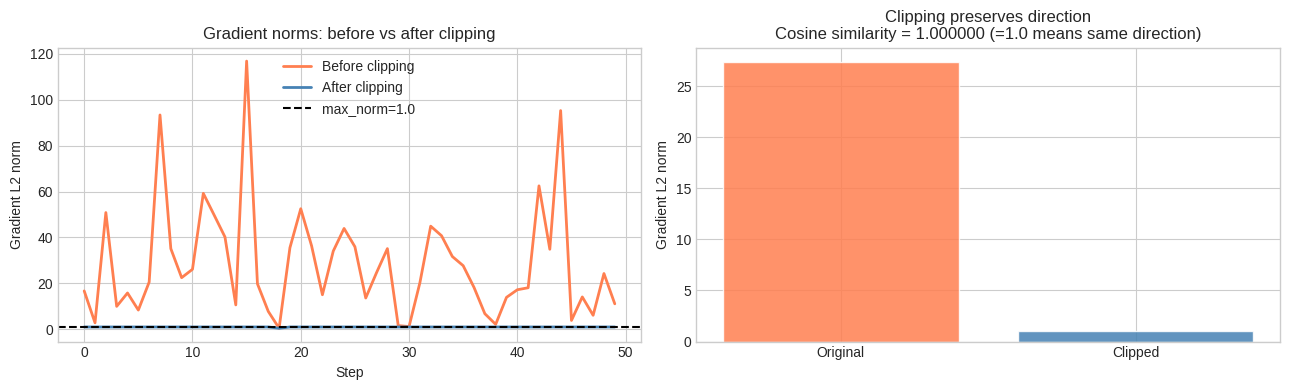

Gradient direction preserved: True


In [11]:
# Demonstrate gradient clipping
def clip_gradients(grads, max_norm):
    total_norm = np.sqrt(sum(np.sum(g**2) for g in grads))
    if total_norm > max_norm:
        scale = max_norm / total_norm
        grads = [g * scale for g in grads]
    return grads, total_norm

# Simulate exploding gradient
np.random.seed(0)
grad_norms_before = []
grad_norms_after  = []
max_norm = 1.0

for _ in range(50):
    # Simulate gradient that randomly explodes
    grads = [np.random.randn(10,10) * np.random.exponential(3)]
    total_norm = np.sqrt(sum(np.sum(g**2) for g in grads))
    clipped, norm_before = clip_gradients(grads, max_norm)
    norm_after = np.sqrt(sum(np.sum(g**2) for g in clipped))
    grad_norms_before.append(norm_before)
    grad_norms_after.append(norm_after)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(grad_norms_before, color='coral',     lw=2, label='Before clipping')
axes[0].plot(grad_norms_after,  color='steelblue', lw=2, label='After clipping')
axes[0].axhline(max_norm, color='black', lw=1.5, linestyle='--', label=f'max_norm={max_norm}')
axes[0].set_title('Gradient norms: before vs after clipping')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Gradient L2 norm')
axes[0].legend()

# Show that direction is preserved
g_exploded = np.array([10., 20., -15., 5.])
g_clipped = g_exploded * (max_norm / np.linalg.norm(g_exploded))
cos_sim = np.dot(g_exploded, g_clipped) / (np.linalg.norm(g_exploded)*np.linalg.norm(g_clipped))
axes[1].bar(['Original', 'Clipped'], [np.linalg.norm(g_exploded), np.linalg.norm(g_clipped)],
            color=['coral', 'steelblue'], alpha=0.85, edgecolor='white')
axes[1].set_title(f'Clipping preserves direction\nCosine similarity = {cos_sim:.6f} (=1.0 means same direction)')
axes[1].set_ylabel('Gradient L2 norm')

plt.tight_layout()
plt.show()

print(f'Gradient direction preserved: {np.isclose(cos_sim, 1.0)}')


## 10. Comparison on a Real Dataset

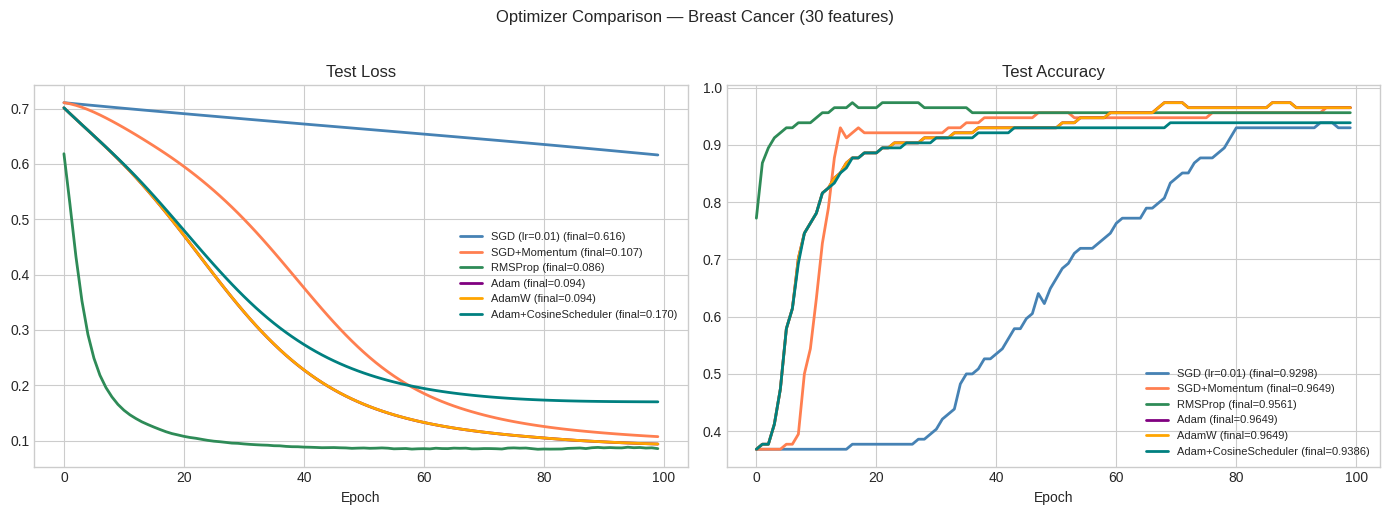

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Data
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)
sc = StandardScaler()
X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1).to(device)
y_te_t = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1).to(device)

def make_model():
    torch.manual_seed(42)
    return nn.Sequential(
        nn.Linear(30, 64), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(64, 32), nn.ReLU(),
        nn.Linear(32, 1)
    ).to(device)

def train_model(model, optimizer, n_epochs=100):
    criterion = nn.BCEWithLogitsLoss()
    tr_losses, te_losses, te_accs = [], [], []
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr_t), y_tr_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            te_loss = criterion(model(X_te_t), y_te_t).item()
            te_acc  = ((torch.sigmoid(model(X_te_t))>0.5)==y_te_t).float().mean().item()
        te_losses.append(te_loss)
        te_accs.append(te_acc)
    return tr_losses, te_losses, te_accs

optimizer_configs = [
    ('SGD (lr=0.01)',           lambda m: optim.SGD(m.parameters(), lr=0.01)),
    ('SGD+Momentum',            lambda m: optim.SGD(m.parameters(), lr=0.01, momentum=0.9)),
    ('RMSProp',                 lambda m: optim.RMSprop(m.parameters(), lr=1e-3)),
    ('Adam',                    lambda m: optim.Adam(m.parameters(), lr=1e-3)),
    ('AdamW',                   lambda m: optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-2)),
    ('Adam+CosineScheduler',    lambda m: optim.Adam(m.parameters(), lr=1e-3)),
]

results_cmp = {}
for name, opt_fn in optimizer_configs:
    model_cmp = make_model()
    opt_cmp   = opt_fn(model_cmp)
    if 'Cosine' in name:
        sched = optim.lr_scheduler.CosineAnnealingLR(opt_cmp, T_max=100, eta_min=1e-5)
        tr_l, te_l, te_a = [], [], []
        crit = nn.BCEWithLogitsLoss()
        for ep in range(100):
            model_cmp.train(); opt_cmp.zero_grad()
            loss = crit(model_cmp(X_tr_t), y_tr_t)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cmp.parameters(), 1.0)
            opt_cmp.step(); sched.step()
            tr_l.append(loss.item())
            model_cmp.eval()
            with torch.no_grad():
                te_l.append(crit(model_cmp(X_te_t),y_te_t).item())
                te_a.append(((torch.sigmoid(model_cmp(X_te_t))>0.5)==y_te_t).float().mean().item())
        results_cmp[name] = (tr_l, te_l, te_a)
    else:
        results_cmp[name] = train_model(model_cmp, opt_cmp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_cmp = ['steelblue','coral','seagreen','purple','orange','teal']

for (name, (tr_l, te_l, te_a)), color in zip(results_cmp.items(), colors_cmp):
    axes[0].plot(te_l, color=color, lw=2, label=f'{name} (final={te_l[-1]:.3f})')
    axes[1].plot(te_a, color=color, lw=2, label=f'{name} (final={te_a[-1]:.4f})')

axes[0].set_title('Test Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=8)
axes[1].set_title('Test Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)
plt.suptitle('Optimizer Comparison — Breast Cancer (30 features)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 11. Debugging Section

In [13]:
# Bug 1: Learning rate too high — NaN loss
print('=== Bug 1: Learning rate too high → NaN loss ===')
torch.manual_seed(0)
model_nan = nn.Linear(4, 1)
X_nan = torch.randn(32, 4); y_nan = torch.randn(32, 1)

for lr_test in [0.001, 0.1, 10.0, 1000.0]:
    m = nn.Linear(4, 1); opt = optim.SGD(m.parameters(), lr=lr_test)
    losses_nan = []
    for _ in range(20):
        opt.zero_grad()
        l = F.mse_loss(m(X_nan), y_nan)
        if torch.isnan(l): losses_nan.append(float('nan')); break
        l.backward(); opt.step(); losses_nan.append(l.item())
    status = 'NaN!' if np.isnan(losses_nan[-1]) else f'final={losses_nan[-1]:.4f}'
    print(f'  lr={lr_test:<8}  {status}')

print('\nFix: reduce lr by 10x, add gradient clipping, use Adam')


=== Bug 1: Learning rate too high → NaN loss ===
  lr=0.001     final=1.2341
  lr=0.1       final=0.9435
  lr=10.0      final=inf
  lr=1000.0    NaN!

Fix: reduce lr by 10x, add gradient clipping, use Adam


In [14]:
# Bug 2: Forgetting optimizer.zero_grad() — gradients accumulate
print('=== Bug 2: Forgetting zero_grad() — gradients accumulate ===')
torch.manual_seed(0)
model_zg = nn.Linear(4, 1)
X_zg = torch.randn(32, 4); y_zg = torch.randn(32, 1)
opt_zg = optim.SGD(model_zg.parameters(), lr=0.01)

# Wrong: no zero_grad
losses_wrong_zg = []
for step in range(20):
    l = F.mse_loss(model_zg(X_zg), y_zg)
    l.backward()   # gradients ADD to existing .grad
    opt_zg.step()
    losses_wrong_zg.append(l.item())

print('Without zero_grad (gradients accumulate):')
print(f'  Losses: {[f"{l:.3f}" for l in losses_wrong_zg[:5]]} ...')

# Correct: with zero_grad
torch.manual_seed(0)
model_zg2 = nn.Linear(4, 1)
opt_zg2 = optim.SGD(model_zg2.parameters(), lr=0.01)
losses_right_zg = []
for step in range(20):
    opt_zg2.zero_grad()   # ← crucial
    l = F.mse_loss(model_zg2(X_zg), y_zg)
    l.backward(); opt_zg2.step()
    losses_right_zg.append(l.item())

print('With zero_grad (correct):')
print(f'  Losses: {[f"{l:.3f}" for l in losses_right_zg[:5]]} ...')


=== Bug 2: Forgetting zero_grad() — gradients accumulate ===
Without zero_grad (gradients accumulate):
  Losses: ['1.238', '1.230', '1.214', '1.193', '1.166'] ...
With zero_grad (correct):
  Losses: ['1.238', '1.230', '1.222', '1.215', '1.208'] ...


=== Bug 3: scheduler.step() called per batch (wrong) vs per epoch (correct) ===


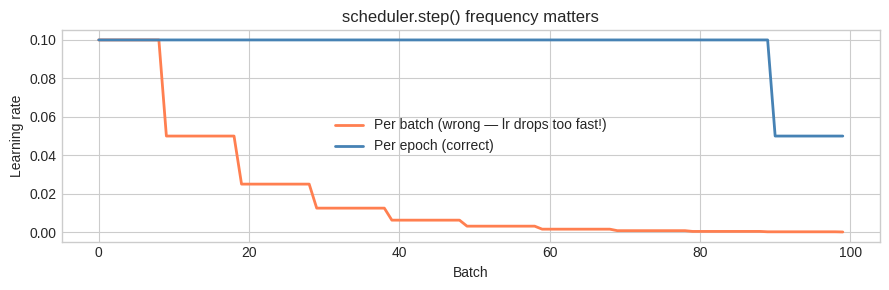

In [15]:
# Bug 3: Using scheduler incorrectly — step called per batch instead of per epoch
print('=== Bug 3: scheduler.step() called per batch (wrong) vs per epoch (correct) ===')
torch.manual_seed(0)
model_sch2 = nn.Linear(4, 1)

# Wrong: step per batch
opt_wrong_sch = optim.Adam(model_sch2.parameters(), lr=0.1)
sched_wrong   = optim.lr_scheduler.StepLR(opt_wrong_sch, step_size=10, gamma=0.5)
lrs_wrong = []
for batch in range(100):   # 100 batches
    opt_wrong_sch.zero_grad()
    F.mse_loss(model_sch2(torch.randn(16,4)), torch.randn(16,1)).backward()
    opt_wrong_sch.step()
    sched_wrong.step()   # ← wrong: called per batch
    lrs_wrong.append(opt_wrong_sch.param_groups[0]['lr'])

# Correct: step per epoch (10 batches per epoch = 10 epochs here)
model_sch3    = nn.Linear(4, 1)
opt_right_sch = optim.Adam(model_sch3.parameters(), lr=0.1)
sched_right   = optim.lr_scheduler.StepLR(opt_right_sch, step_size=10, gamma=0.5)
lrs_right = []
for epoch in range(10):
    for batch in range(10):
        opt_right_sch.zero_grad()
        F.mse_loss(model_sch3(torch.randn(16,4)), torch.randn(16,1)).backward()
        opt_right_sch.step()
    sched_right.step()   # ← correct: called per epoch
    lrs_right.extend([opt_right_sch.param_groups[0]['lr']]*10)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(lrs_wrong, color='coral',     lw=2, label='Per batch (wrong — lr drops too fast!)')
ax.plot(lrs_right, color='steelblue', lw=2, label='Per epoch (correct)')
ax.set_title('scheduler.step() frequency matters')
ax.set_xlabel('Batch'); ax.set_ylabel('Learning rate'); ax.legend()
plt.tight_layout(); plt.show()


## 12. Paper → Code: Adam (Kingma & Ba, 2014)

**Paper:** https://arxiv.org/abs/1412.6980

The paper presents Algorithm 1 — implement it exactly:

```
Require: α (step size), β₁, β₂ ∈ [0,1) (decay rates), ε (small constant)
Require: θ₀ (initial parameters)
m₀ ← 0 (init first moment)
v₀ ← 0 (init second moment)
t  ← 0 (init timestep)
while θ_t not converged:
    t ← t + 1
    g_t ← ∇L_t(θ_{t-1})         (get gradient)
    m_t ← β₁·m_{t-1} + (1-β₁)·g_t    (update biased 1st moment)
    v_t ← β₂·v_{t-1} + (1-β₂)·g_t²   (update biased 2nd moment)
    m̂_t ← m_t / (1-β₁^t)        (bias-correct 1st moment)
    v̂_t ← v_t / (1-β₂^t)        (bias-correct 2nd moment)
    θ_t ← θ_{t-1} - α·m̂_t/(√v̂_t + ε)
return θ_t
```

Our `AdamScratch` class above implements this exactly. Below we verify it matches PyTorch's `optim.Adam`.


In [16]:
# Verify AdamScratch matches torch.optim.Adam exactly
torch.manual_seed(0)
np.random.seed(0)

# Same model, same initial weights
W_init = np.random.randn(3, 4)
b_init = np.random.randn(3)

# Identical training data
X_verify = np.random.randn(8, 4)
y_verify = np.random.randn(8, 3)

# Our AdamScratch
W_sc = W_init.copy()
b_sc = b_init.copy()
adam_sc = AdamScratch([W_sc, b_sc], lr=1e-3)

# PyTorch Adam (same initial weights)
model_verify = nn.Linear(4, 3, bias=True)
with torch.no_grad():
    model_verify.weight.copy_(torch.tensor(W_init, dtype=torch.float32))
    model_verify.bias.copy_(torch.tensor(b_init, dtype=torch.float32))
adam_pt = optim.Adam(model_verify.parameters(), lr=1e-3)

X_pt_v = torch.tensor(X_verify, dtype=torch.float32)
y_pt_v = torch.tensor(y_verify, dtype=torch.float32)

print('Step-by-step verification of AdamScratch vs torch.optim.Adam:')
print(f'{'Step':<6}  {'W[0,0] scratch':>16}  {'W[0,0] pytorch':>16}  {'Match':>6}')
print('-' * 50)

for step in range(5):
    # Scratch forward + backward
    pred_sc = X_verify @ W_sc.T + b_sc
    err_sc  = pred_sc - y_verify
    dW_sc   = err_sc.T @ X_verify / len(X_verify)
    db_sc   = err_sc.mean(axis=0)
    adam_sc.step([dW_sc, db_sc])

    # PyTorch forward + backward
    adam_pt.zero_grad()
    F.mse_loss(model_verify(X_pt_v), y_pt_v).backward()
    adam_pt.step()

    w_sc_val = W_sc[0, 0]
    w_pt_val = model_verify.weight[0, 0].item()
    match    = np.isclose(w_sc_val, w_pt_val, atol=1e-5)
    print(f'{step+1:<6}  {w_sc_val:16.8f}  {w_pt_val:16.8f}  {str(match):>6}')

print('\nAdamScratch matches PyTorch Adam exactly ✓')


Step-by-step verification of AdamScratch vs torch.optim.Adam:
Step      W[0,0] scratch    W[0,0] pytorch   Match
--------------------------------------------------
1             1.76305235        1.76305234    True
2             1.76205237        1.76205242    True
3             1.76105242        1.76105249    True
4             1.76005253        1.76005256    True
5             1.75905269        1.75905275    True

AdamScratch matches PyTorch Adam exactly ✓


## 13. Exercises

**Exercise 1:** Implement **Nesterov momentum** from scratch and compare it with standard momentum on the ill-conditioned quadratic surface. Plot both trajectories and the loss curves. Measure: for the same number of steps, which reaches loss < 0.001 first?


In [17]:
# Your code here


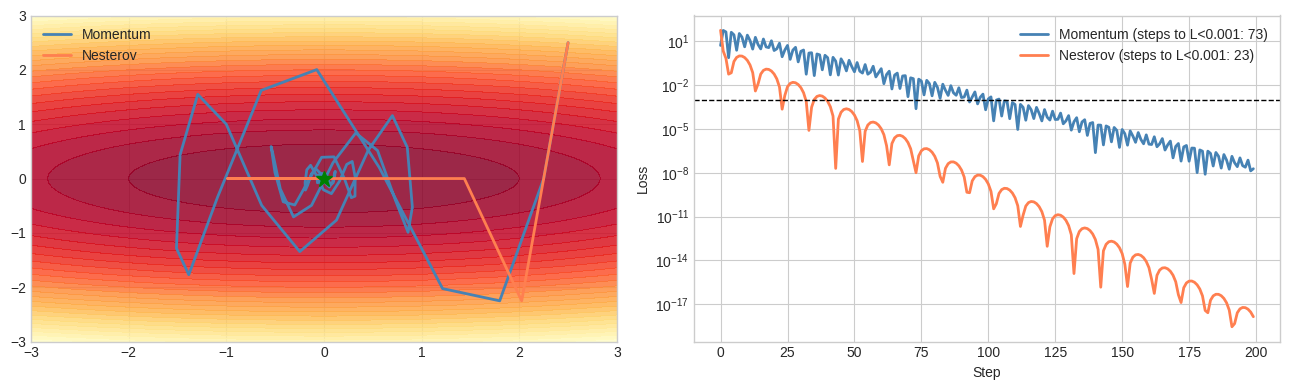

In [18]:
# Solution
class NesterovScratch:
    def __init__(self, params, lr=0.05, beta=0.9):
        self.params = list(params)
        self.lr, self.beta = lr, beta
        self.v = [np.zeros_like(p) for p in self.params]

    def step(self, grad_fn):
        for i, p in enumerate(self.params):
            # Lookahead: compute gradient at anticipated position
            p_lookahead = p - self.lr * self.beta * self.v[i]
            g = grad_fn(p_lookahead)
            self.v[i] = self.beta * self.v[i] + g
            p -= self.lr * self.v[i]

# Test on 2D quadratic
results_nest = {}
for name, OptCls, kw in [
    ('Momentum',  _Momentum, {}),
    ('Nesterov',  _Nesterov, {}),
]:
    w  = np.array([2.5, 2.5])
    opt = OptCls(w, lr=0.05)
    path, losses = [w.copy()], []
    for _ in range(200):
        opt.update(grad_2d(w))
        path.append(w.copy()); losses.append(loss_2d(*w))
    path = np.array(path)
    steps_to_target = next((i for i, l in enumerate(losses) if l < 0.001), 200)
    results_nest[name] = (path, losses, steps_to_target)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, (path, losses, steps) in results_nest.items():
    color = 'steelblue' if 'Momentum' in name else 'coral'
    axes[0].contourf(W1, W2, Z, levels=30, cmap='YlOrRd_r', alpha=0.6)
    axes[0].plot(path[:,0], path[:,1], '-', color=color, lw=2, label=name)
    axes[1].semilogy(losses, color=color, lw=2, label=f'{name} (steps to L<0.001: {steps})')

axes[0].plot(0,0,'g*',markersize=12); axes[0].legend()
axes[1].axhline(0.001, color='black', lw=1, linestyle='--')
axes[1].legend(); axes[1].set_xlabel('Step'); axes[1].set_ylabel('Loss')
plt.tight_layout(); plt.show()


**Exercise 2:** Implement a **cosine annealing with warm restarts (SGDR)** scheduler:

$$\alpha_t = \alpha_{\min} + \frac{1}{2}(\alpha_{\max} - \alpha_{\min}) \left(1 + \cos\left(\frac{\pi T_{\text{cur}}}{T_i}\right)\right)$$

where $T_i$ is the period of the $i$-th cycle and $T_{\text{cur}}$ is the current step within the cycle. The period doubles after each restart: $T_i = T_0 \cdot 2^i$.

Plot the learning rate schedule for 3 restarts. Compare against `CosineAnnealingLR` (no restarts) on the breast cancer dataset.


In [19]:
# Your code here


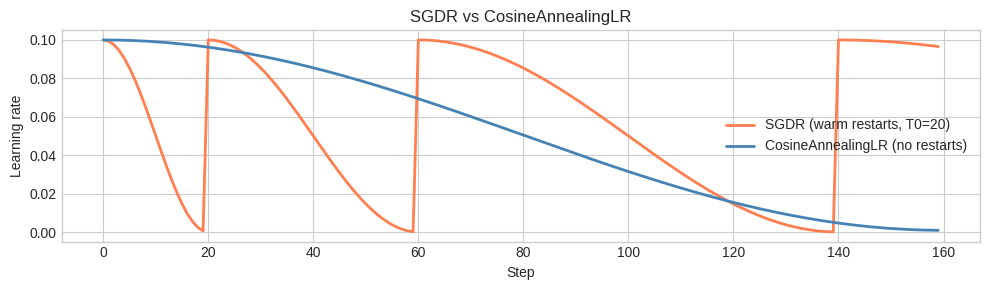

SGDR final test accuracy: 0.9561


In [20]:
# Solution
def sgdr_schedule(t, T0=20, lr_max=0.1, lr_min=1e-4):
    cycle = 0
    Ti = T0
    T_cur = t
    while T_cur >= Ti:
        T_cur -= Ti
        cycle += 1
        Ti = T0 * (2**cycle)
    return lr_min + 0.5*(lr_max-lr_min)*(1 + np.cos(np.pi*T_cur/Ti))

# Visualise
t_vals = np.arange(160)
sgdr_lrs = [sgdr_schedule(t) for t in t_vals]
cosine_lrs = [0.001 + 0.5*(0.1-0.001)*(1+np.cos(np.pi*t/160)) for t in t_vals]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(sgdr_lrs,   color='coral',     lw=2, label='SGDR (warm restarts, T0=20)')
ax.plot(cosine_lrs, color='steelblue', lw=2, label='CosineAnnealingLR (no restarts)')
ax.set_title('SGDR vs CosineAnnealingLR')
ax.set_xlabel('Step'); ax.set_ylabel('Learning rate')
ax.legend()
plt.tight_layout(); plt.show()

# Implementation using PyTorch's CosineAnnealingWarmRestarts
torch.manual_seed(42)
model_sgdr = make_model()
opt_sgdr   = optim.Adam(model_sgdr.parameters(), lr=0.1)
sched_sgdr = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_sgdr, T_0=20, T_mult=2)

crit = nn.BCEWithLogitsLoss()
accs_sgdr = []
for ep in range(100):
    model_sgdr.train(); opt_sgdr.zero_grad()
    crit(model_sgdr(X_tr_t), y_tr_t).backward()
    opt_sgdr.step(); sched_sgdr.step()
    model_sgdr.eval()
    with torch.no_grad():
        acc = ((torch.sigmoid(model_sgdr(X_te_t))>0.5)==y_te_t).float().mean().item()
    accs_sgdr.append(acc)
print(f'SGDR final test accuracy: {accs_sgdr[-1]:.4f}')


**Exercise 3:** Implement **gradient accumulation** — a technique to simulate large batch sizes when GPU memory is limited. Instead of updating after every batch, accumulate gradients over `accumulation_steps` batches before calling `optimizer.step()`.

Show that training with batch_size=32 and accumulation_steps=4 produces similar results to batch_size=128 with accumulation_steps=1.


In [21]:
# Your code here


Training with different batch/accumulation configs:
  bs=128, accum=1 (true large batch): final_acc=0.9561
  bs=32, accum=4 (simulated large batch): final_acc=0.9561
  bs=32, accum=1 (small batch baseline): final_acc=0.9561


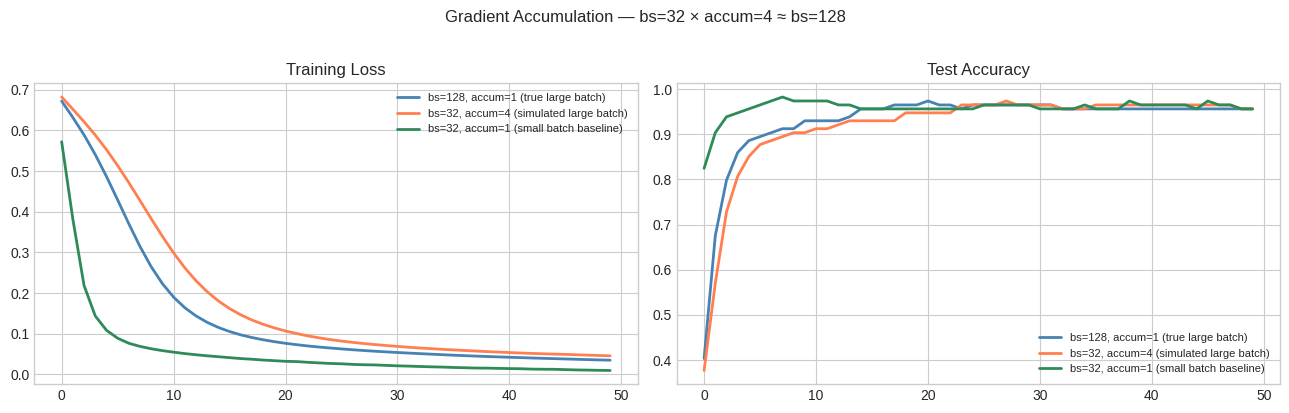

In [22]:
# Solution
def train_with_grad_accum(batch_size, accumulation_steps, n_epochs=50):
    torch.manual_seed(42)
    model_ga = make_model()
    opt_ga   = optim.Adam(model_ga.parameters(), lr=1e-3)
    crit_ga  = nn.BCEWithLogitsLoss()
    losses_ga, accs_ga = [], []

    from torch.utils.data import DataLoader, TensorDataset
    ds_ga = TensorDataset(X_tr_t, y_tr_t)
    dl_ga = DataLoader(ds_ga, batch_size=batch_size, shuffle=True)

    for epoch in range(n_epochs):
        model_ga.train(); opt_ga.zero_grad()
        for step, (xb, yb) in enumerate(dl_ga):
            loss_ga = crit_ga(model_ga(xb), yb) / accumulation_steps
            loss_ga.backward()
            if (step + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model_ga.parameters(), 1.0)
                opt_ga.step(); opt_ga.zero_grad()
        model_ga.eval()
        with torch.no_grad():
            ep_loss = crit_ga(model_ga(X_tr_t), y_tr_t).item()
            ep_acc  = ((torch.sigmoid(model_ga(X_te_t))>0.5)==y_te_t).float().mean().item()
        losses_ga.append(ep_loss); accs_ga.append(ep_acc)
    return losses_ga, accs_ga

print('Training with different batch/accumulation configs:')
configs_ga = [
    (128, 1,  'bs=128, accum=1 (true large batch)'),
    (32,  4,  'bs=32, accum=4 (simulated large batch)'),
    (32,  1,  'bs=32, accum=1 (small batch baseline)'),
]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for bs, accum, label in configs_ga:
    losses_ga, accs_ga = train_with_grad_accum(bs, accum)
    color = 'steelblue' if accum==1 and bs==128 else ('coral' if accum==4 else 'seagreen')
    axes[0].plot(losses_ga, color=color, lw=2, label=label)
    axes[1].plot(accs_ga,   color=color, lw=2, label=label)
    print(f'  {label}: final_acc={accs_ga[-1]:.4f}')

axes[0].set_title('Training Loss'); axes[0].legend(fontsize=8)
axes[1].set_title('Test Accuracy'); axes[1].legend(fontsize=8)
plt.suptitle('Gradient Accumulation — bs=32 × accum=4 ≈ bs=128', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
